In [68]:
import pandas as pd
import numpy as np 
import re
import gradio as gr
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')


In [69]:
import kagglehub

path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Krishna\.cache\kagglehub\datasets\dylanjcastillo\7k-books-with-metadata\versions\3


In [70]:
df = pd.read_csv(f'{path}/books.csv')

In [71]:
# Preview first five rows of the dataframe
df.head(5)

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


<Axes: >

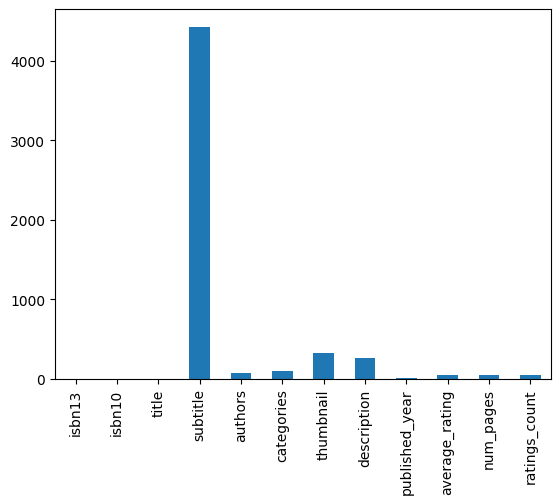

In [72]:
df.isna().sum().plot(kind='bar')

In [73]:
df.columns

Index(['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories',
       'thumbnail', 'description', 'published_year', 'average_rating',
       'num_pages', 'ratings_count'],
      dtype='object')

In [74]:
len(df['categories'].unique())

568

Text(0.5, 0, 'Categories')

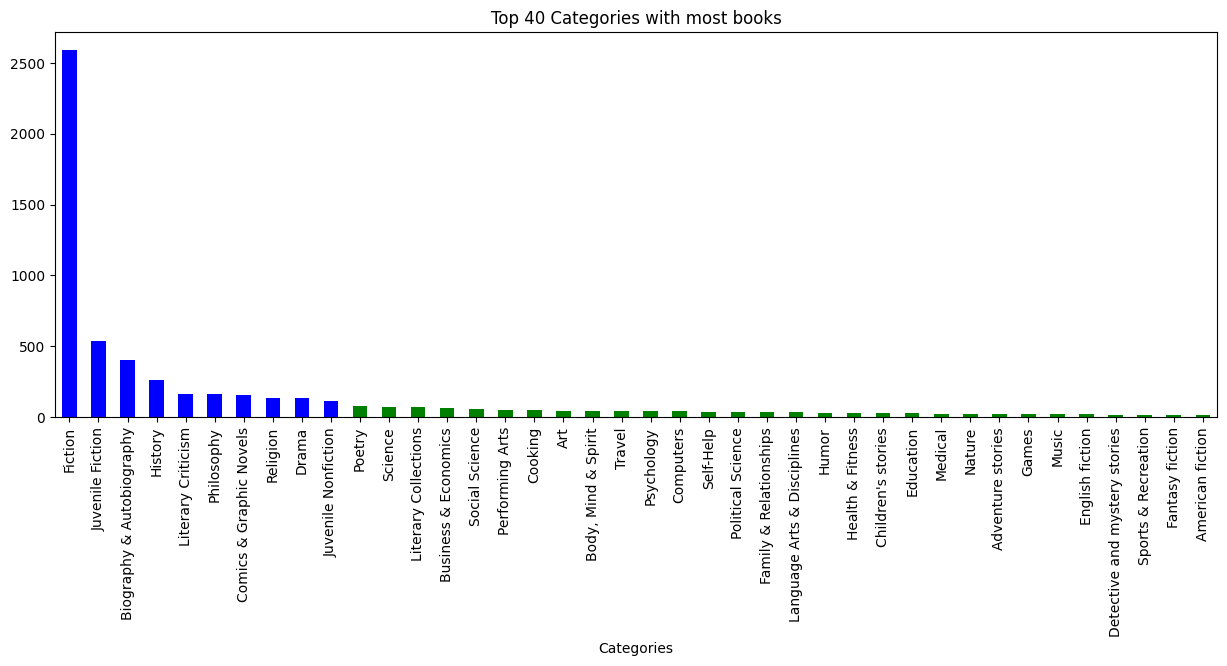

In [75]:
color = ['blue' if x > 100 else 'green' for x in df['categories'].value_counts()[:40]]
plt.figure(figsize=(15, 5))
df['categories'].value_counts()[:40].plot(kind='bar', color=color)
plt.title('Top 40 Categories with most books')
plt.xlabel('Categories')

Text(0, 0.5, 'Number of Books')

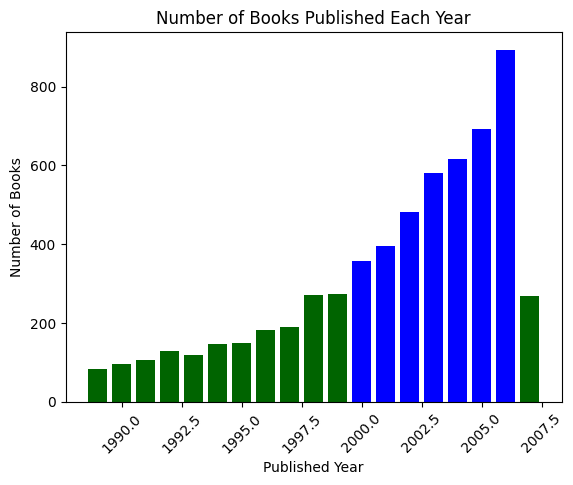

In [76]:
books_year_publishing = df['published_year'].value_counts()
books_year_publishing = books_year_publishing[books_year_publishing >= books_year_publishing.mean()]
c = ['blue' if x >= 300 else 'darkgreen' for x in books_year_publishing]
plt.bar(books_year_publishing.index, books_year_publishing.values, color=c)
plt.xticks(rotation=45)
plt.title('Number of Books Published Each Year')
plt.xlabel('Published Year')
plt.ylabel('Number of Books')


Text(0.5, 1.0, 'Missing Values in the Dataset')

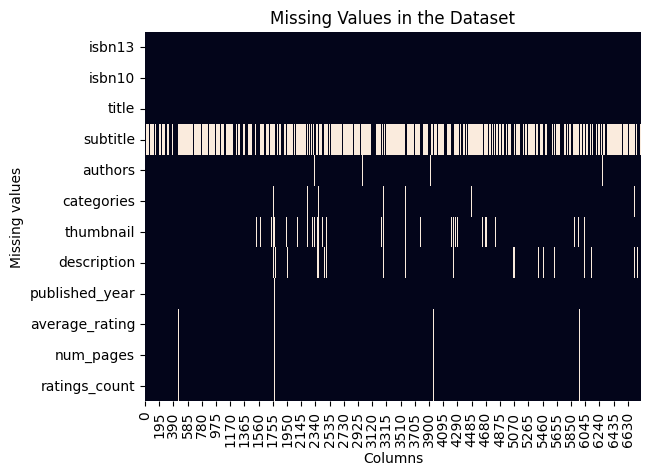

In [77]:
ax = plt.axes()

sns.heatmap(df.isna().transpose(), ax=ax, cbar=False)
plt.xlabel('Columns')
plt.ylabel('Missing values')
plt.title('Missing Values in the Dataset')

**The heatmap reveals a pattern in missing data, so further investigation is needed to understand the cause and prevent bias during data cleaning.**

In [78]:
df['missing_description'] = np.where(df['description'].isna(), 1, 0)
df['book_age'] = 2025 - df['published_year']

<Axes: >

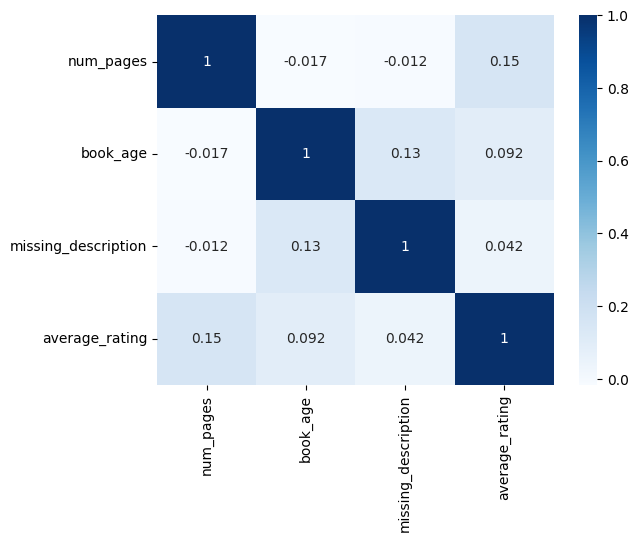

In [79]:
col_of_interest = ['num_pages', 'book_age', 'missing_description', 'average_rating']
sns.heatmap(df[col_of_interest].corr(method='spearman'), cmap='Blues', annot=True)

<Axes: >

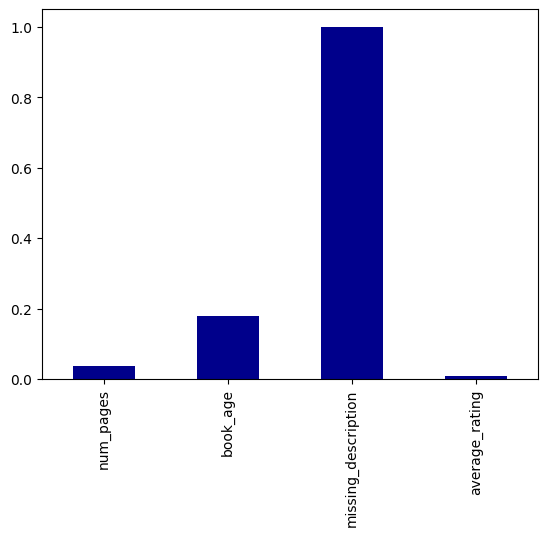

In [80]:
corr = df[col_of_interest].corrwith(df['missing_description'])
corr.plot(kind='bar', color='darkblue')

In [81]:
col_of_interest

['num_pages', 'book_age', 'missing_description', 'average_rating']

In [82]:
df = df[~(df['num_pages'].isna()) &
        (~df['average_rating'].isna()) &
        (~df['description'].isna()) &
        (~df['published_year'].isna())
]

In [83]:
df.head(3)

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,book_age
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,21.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,25.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,0,43.0


**We will check the description's length to ensure it contains meaningful information for vector search, and to do so:**

*we will create a new column with the number of element in each description col and we will use 4 bins.*

In [84]:
df['words_in_description'] = df['description'].str.split().str.len()

Text(0.5, 0, 'Number of Words in Description')

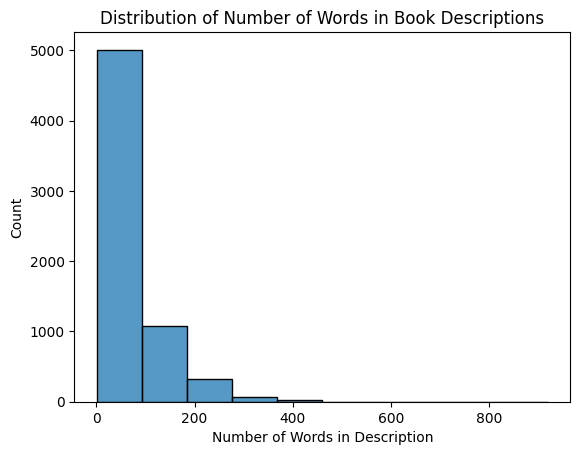

In [85]:
sns.histplot(df['words_in_description'], bins=10)
plt.title('Distribution of Number of Words in Book Descriptions')
plt.xlabel('Number of Words in Description')

In [86]:
# Descriptions where the word count is between 1 and 4
df['description'][df['words_in_description'].between(1, 4)]

6                                           Donation.
11                                     Fantasy-roman.
748              Includes bibliographical references.
770                             Bound For Oregon (PB)
775                                No Marketing Blurb
812                                No Marketing Blurb
857                          First published in 1813.
944                         Edited by Maurice Hindle.
953                        DEFOE/ROBINSON CRUSOE (BC)
954                             Edited by John Carey.
962                         ALLEN/GETTING THINGS DONE
1054                            GILBERT/EAT PRAY LOVE
1056    "Graham Greene centennial, 1904-2004"--Cover.
1060                   STEINBECK/GRAPES OF WRATH (BC)
1346                                   Fantasy-roman.
1546                                      Winter 2003
1610                                      Winter 1999
1813                             National bestseller.
1981                        

In [87]:
# Descriptions where the word count is between 5 and 14
df['description'][df['words_in_description'].between(5, 14)]

2       Volume Two of Stephen Donaldson's acclaimed se...
38      Koko is Peter Straub's foray into the psycholo...
70      A matter of life and death - and the Throne of...
77                         Nonsense rhyming story. 4 yrs+
84      A study guide for the novel There's a Boy in t...
                              ...                        
6715    The first comprehensive guide to addressing Na...
6726       Presents two complete novels from Henry James.
6757                          Audio Book- unabriged on CD
6776    Raymond Chandler meets The Exorcist. Classic n...
6795    Book Of Five Rings is a Kodansha International...
Name: description, Length: 308, dtype: object

In [88]:
# Descriptions where the word count is between 15 and 24
df['description'][df['words_in_description'].between(15, 24)]

10      One of Sidney Sheldon's most popular and bests...
32      Tells the story of three generations of Chines...
36      A magical and fantastic collection of early st...
57      A young drifter finds more than he bargained f...
68      A new 'The Doors of Perception' for the 21st c...
                              ...                        
6767    Everything from the fingerprints of the gods t...
6782    Displays one of America's leading physicist's ...
6783    Basics Illustration 01: Thinking Visually expl...
6789    Provides an introduction to the American artis...
6809    This is a jubilant and rewarding collection of...
Name: description, Length: 947, dtype: object

In [89]:
# Descriptions where the word count is between 25 and 34
df['description'][df['words_in_description'].between(25, 34)]

9       Kate Blackwell is an enigma and one of the mos...
14      Available in the U.S. for the first time, this...
20      It is 1937, and Charles Ashworth, a Canon to t...
21      Reissue of the author's most famous and well-l...
46      No one believes a little girl when she insists...
                              ...                        
6760    Joel, an English teacher, has never really lik...
6766    Discusses the historical and intellectual back...
6775    Presents nearly one thousand recipes--from app...
6779    Edited by the creator and executive producer o...
6799    This book is the story of a young girl obsesse...
Name: description, Length: 1229, dtype: object

**Rows with description lengths less than 24 words will be removed.**

In [90]:
len(df) - len(df['description'][df['words_in_description'].between(0, 24)])

5197

In [91]:
df = df[df['words_in_description'] >= 25]
len(df)

5197

In [92]:
df['title and subtitle'] = np.where(
    df['subtitle'].isna(),
    df['title'],
    df[['title', 'subtitle']].astype(str).agg(": ".join, axis=1)
)

**For indexing purposes, we will combine the unique index with the description.**

In [93]:
df['tagged_description'] = df[['isbn13', 'description']].astype(str).agg(" ".join, axis=1)

In [94]:
df.columns

Index(['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories',
       'thumbnail', 'description', 'published_year', 'average_rating',
       'num_pages', 'ratings_count', 'missing_description', 'book_age',
       'words_in_description', 'title and subtitle', 'tagged_description'],
      dtype='object')

In [95]:
(
    df.drop(['subtitle', 'missing_description', 'book_age', 'words_in_description'], axis=1).to_csv('df_cleaned.csv', index=False)
)